# Goal

sPCA was fit on *pseudobulk* profiles. If, in a combinatorial condition `L1_L2`, ligand L1
induces genes A,B in half the cells and L2 induces genes C,D in the other half, the pseudobulk
sees A,B,C,D all elevated and bundles them into one component -- even though no single cell
expresses the "program." This notebook checks whether that happened.

## What this notebook does, in order

1. **Gate** to consistent interactions x components with a significant condition-level effect.
2. **Load and scale expression** the same way it was scored upstream. Separately build the
   pseudobulk sPCA was fit on.
3. **Partition each component into two gene sub-modules**, from pseudobulk co-expression only --
   fixed before any cell is scored.
4. **Score both halves per cell and correlate them**: `r = spearman(score_A, score_B)`.
   High = one program, low/negative = two.
5. **Look at the result**: overall, by interaction class, against power, and cell-by-cell for
   the synergy pairs at both ends of the range.


## Setup

Paths, constants, and the `cnsplots` figure style. Nothing here is a threshold on `r` -- the
only gates are the lm significance level and the replicate-reproducibility filter.


In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"

import os
import time
from collections import namedtuple

import anndata as ad
import cnsplots as cns
import decoupler as dc
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from joblib import Parallel, delayed
from scipy import stats
from sklearn.cluster import KMeans

# ---- inputs -----------------------------------------------------------------------------------
H5AD = f"{IMPORTS_DIR}/SIG13/scanpy_outs/SIG13_doublets_DSB7.h5ad"
LAYER = "log1p_norm"
# the z-scored, DEG-filtered input the sPCA fit itself used
# (07_spca/01_spca_degs_zscore_expression_allLigands.py) -- used ONLY to build the pseudobulk that section 3
# partitions components on, so the sub-modules are identified on the same matrix the components
# were fit on. Per-cell scoring (section 4 on) stays on the scaled log1p_norm matrix above.
ZSCORE_H5AD = f"{IMPORTS_DIR}/SIG13/scanpy_outs/SIG13_doublets_DSB7_zscore_degs0.1cutoff.h5ad"
SPCA_DIR = f"{IMPORTS_DIR}/SIG13/analysis_outs/spca"
OUTDIR = f"{OUTS_DIR}/spca_coherence_simple"
FIGDIR = f"{OUTDIR}/figures"
LOADINGS = f"{SPCA_DIR}/zscore_degs_allLigands_0.1_alpha1.0_sPCA_loadings.csv"
# condition-level lm: one coefficient per condition (`interaction<L1>_<L2>`), i.e. the overall
# effect of the condition, not the interaction contrast
LM_FIT_COND = f"{SPCA_DIR}/lm_fit_condition_zscore_degs_allLigands_0.1_alpha1.0_sPCA_clean.csv"
# scored interaction table: per (component, interaction) interaction class and score
LM_SCORED = f"{SPCA_DIR}/lm_scored_zscore_degs_allLigands_0.1_alpha1.0_sPCA_clean.csv"
REPCORR = (f"{IMPORTS_DIR}/SIG13/analysis_outs/replicate_corr/"
           "replicate_correlation_interactionLfc_0.2filter.csv")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

# ---- analysis constants -----------------------------------------------------------------------
GROUP_KEY = "ligand_call_DSB7"

CORR_GATE, NSHARED_GATE = 0.25, 1   # repo-canonical "consistent interaction"

# p-value and effect size cutoffs for components to investigate
LM_ALPHA = 0.01                  
LM_ESTIMATE_ABS = 0.5

MIN_CELLS = 100                     # below this a within-condition correlation is not estimable
N_INIT = 25                         # k-means restarts
SEED = 0

N_JOBS = int(os.environ.get("N_JOBS", "8"))

In [2]:
cns.palettes("Set1")[1]

(0.21568627450980393, 0.49411764705882355, 0.7215686274509804)

In [3]:
# ---- cnsplots figure style --------------------------------------------------------------------
# Arial is not installed on this machine, and neither is cnsplots' default Helvetica -- without
# this the run logs `findfont: Font family 'Helvetica' not found` for every label and silently
# falls back to DejaVu Sans. Nimbus Sans (urw-base35, shipped with the OS) is the Helvetica/Arial
# metric clone; it embeds as TrueType under `pdf_fonttype = 42`, so PDF text stays editable.
cns.settings.font_sans_serif = ("Nimbus Sans", "Arial", "Helvetica", "DejaVu Sans")
cns.settings.panel_label_fontname = "Nimbus Sans"     # default is Helvetica, resolved by name
cns.setup_matplotlib()
# `cns.savefig` runs `apply_unicode_font`, which switches any text containing a NON-ASCII character
# to DejaVu Sans. matplotlib's default negative tick label uses U+2212, so every axis with negative
# values would come out in a different font from the rest of the figure. ASCII hyphen instead.
plt.rcParams["axes.unicode_minus"] = False

R_LO, R_HI = -0.85, 1.02            # common axis limits for every r axis (display only)
R_LABEL = "sub-module correlation, Spearman r"
R_LABEL_SHORT = "sub-module correlation, r"   # multi-panel axes are too short for the full one

# Interaction classes, from the scored lm table. Ordered null -> strongest departure.
CLASS_ORDER = ["none", "buffering", "synergy positive", "synergy negative"]
CLASS_COLORS = {"none": "#666666FF", "buffering": "#D95F02FF",
                "synergy positive": "#66A61EFF", "synergy negative": "#E7298AFF"}
CLASS_SHORT = {"none": "none", "buffering": "buffering",
               "synergy positive": "synergy +", "synergy negative": "synergy -"}


def savefig(name: str) -> None:
    """Write the current cnsplots figure as PDF and show it inline."""
    cns.savefig(f"{FIGDIR}/{name}.pdf")
    plt.show()


def flag(s: pd.Series) -> pd.Series:
    """Object-dtype boolean columns -> real booleans, without the fillna downcast warning."""
    return s.eq(True)

## 1. Which interactions to test

Restricted to consistent interactions whose **condition-level** lm coefficient is significant
for that component -- the overall effect of the condition, not the interaction contrast. Gating
on the interaction contrast instead would have selected only pairs the interaction model already
calls non-additive, making the class comparison in section 7 circular.

* **Consistent** = the repo-canonical replicate-reproducibility filter (`pearson_corr > 0.25 &
  num_shared_genes > 1`), 146 interactions.
* Single-ligand arms (`<L>_linker`, `linker_<L>`) and self-pairs are dropped.

Each surviving pair is then annotated with its interaction class (`none`, `buffering`, `synergy
positive`, `synergy negative`) and score, used only in section 7 -- never to select pairs.


In [4]:
rc = pd.read_csv(REPCORR)
consistent = set(rc.loc[(rc.pearson_corr > CORR_GATE)
                        & (rc.num_shared_genes > NSHARED_GATE), "interaction"])
print(f"consistent interactions: {len(consistent)}")

lm = pd.read_csv(LM_FIT_COND)
it = lm[lm.term.str.startswith("interaction")].copy()
it["interaction"] = it.term.str.removeprefix("interaction")
it[["ligand1", "ligand2"]] = it.interaction.str.rsplit("_", n=1, expand=True)
it = it[(it.ligand1 != "linker") & (it.ligand2 != "linker")]      # drop single-ligand arms

# gate by p-value, effect size, and reproducibility (consistent interaction)
gated = it[(it.p_adj < LM_ALPHA) & (it.interaction.isin(consistent)) & (it.estimate.abs() > LM_ESTIMATE_ABS)].copy()
gated = gated.rename(columns={"estimate": "lm_estimate_condition",
                              "p_adj": "lm_p_adj_condition"})
gated["is_self_pair"] = gated.ligand1 == gated.ligand2
# remove self pairs
gated = gated[~gated.is_self_pair].copy()

# a pair's mirror is the same ligands in the opposite barcode round -- independent wells, so
# agreement between the two is a free reproducibility check (see the mirror figure)
present = set(gated.interaction)
gated["mirror_interaction"] = [f"{b}_{a}" if f"{b}_{a}" in present else None
                               for a, b in zip(gated.ligand1, gated.ligand2)]
gated = gated[["interaction", "component", "ligand1", "ligand2", "is_self_pair",
               "mirror_interaction", "lm_estimate_condition",
               "lm_p_adj_condition"]].reset_index(drop=True)

# interaction class / score, for the section 8 breakdown only -- never a selection criterion
scored = pd.read_csv(LM_SCORED)[["component", "interaction", "interaction_class",
                                 "interaction_score", "estimate_interaction",
                                 "p_adj_interaction"]]
gated = gated.merge(scored, on=["component", "interaction"], how="left")
gated["interaction_class"] = gated.interaction_class.fillna("unclassified")

print(f"[gate] {len(gated):,} pairs | {gated.interaction.nunique()} interactions | "
      f"{gated.component.nunique()} components | {gated.is_self_pair.sum()} self-pairs")
print(gated.interaction_class.value_counts().to_string())
gated.head()

consistent interactions: 146
[gate] 5,882 pairs | 138 interactions | 68 components | 0 self-pairs
interaction_class
none                3518
buffering           2019
synergy positive     251
unclassified          67
synergy negative      27


,interaction,component,ligand1,ligand2,is_self_pair,mirror_interaction,lm_estimate_condition,lm_p_adj_condition,interaction_class,interaction_score,estimate_interaction,p_adj_interaction
0,IFNG_CCL19,comp_0,IFNG,CCL19,False,None,0.511798,1.898541e-03,none,0.000000,-0.212160,0.999978
1,IFNG_IFNA,comp_0,IFNG,IFNA,False,None,3.450270,1.855915e-82,none,0.000000,-0.282402,0.999978
2,IFNG_IFNB1,comp_0,IFNG,IFNB1,False,None,4.279498,2.472968e-112,buffering,-0.141313,-0.604748,0.066575
3,IFNG_IFNK,comp_0,IFNG,IFNK,False,None,3.363504,2.334566e-79,none,0.000000,-0.316750,0.895878
4,IFNG_IL2,comp_0,IFNG,IL2,False,IL2_IFNG,-0.644592,7.072337e-05,none,0.000000,-0.018934,0.999978


The sPCA loadings are the weights used everywhere below -- the same numbers the component was
originally scored with, never refit. Grouped by component, they define each program's gene set.


In [5]:
net = (pd.read_csv(LOADINGS)
       .rename(columns={"gene": "target", "spca_component": "source", "loading": "weight"}))
genes = sorted(net.target.unique())
net_by_comp = {c: d for c, d in net.groupby("source")}
print(f"[loadings] {len(net):,} nonzero weights | {len(genes):,} genes | "
      f"{len(net_by_comp)} components")
print(f"[loadings] min weight {net.weight.min():+.3e}, "
      f"{(net.weight < 0).sum()} negative  <- all positive, so decoupler's sum(w) denominator "
      f"equals the sum(|w|) of the waggr definition")

[loadings] 19,382 nonzero weights | 6,610 genes | 78 components
[loadings] min weight +2.490e-07, 0 negative  <- all positive, so decoupler's sum(w) denominator equals the sum(|w|) of the waggr definition


## 2. Scale the expression matrix

Per-cell scoring (section 4 on) runs on expression scaled the same way it was scored upstream:
`sc.pp.scale` over the whole matrix, nothing subset beforehand. Only `layers/log1p_norm`,
restricted to the loading genes, is read in row chunks (the full h5ad is 39 GB; the loading-gene
subset is 349,678 x 6,610 float32, ~9.2 GB).

The pseudobulk that section 3 partitions components on is a **separate** matrix: the z-scored,
DEG-filtered input the sPCA fit itself used, aggregated the same way the fitting script
aggregated it. Scoring and partitioning intentionally run on different matrices, matched to what
each step needs.


In [6]:
t0 = time.time()
with h5py.File(H5AD, "r") as f:
    obs = ad.io.read_elem(f["obs"])
    var_names = ad.io.read_elem(f["var"]).index
    missing = set(genes) - set(var_names)
    assert not missing, f"{len(missing)} loading genes absent from var: {sorted(missing)[:10]}"

    gidx = np.sort(pd.Series(np.arange(len(var_names)), index=var_names)[genes].to_numpy())
    D = ad.io.sparse_dataset(f[f"layers/{LAYER}"])
    Xd = np.empty((D.shape[0], gidx.size), dtype=np.float32)
    CHUNK = 20_000
    for start in range(0, D.shape[0], CHUNK):
        end = min(start + CHUNK, D.shape[0])
        Xd[start:end] = D[start:end][:, gidx].toarray()

adata = ad.AnnData(X=Xd, obs=obs[[GROUP_KEY, "replicate"]].astype(str).copy(),
                   var=pd.DataFrame(index=var_names[gidx]))
del Xd, obs
print(f"[load] {adata.shape} ({adata.X.nbytes / 1e9:.1f} GB) in {time.time() - t0:.0f}s")
adata


[load] (349678, 6610) (9.2 GB) in 18s


AnnData object with n_obs × n_vars = 349678 × 6610
    obs: 'ligand_call_DSB7', 'replicate'

In [7]:
# scaling statistics over ALL cells, as in the upstream per-cell scoring
t0 = time.time()
sc.pp.scale(adata)
X = adata.X
gene_pos = pd.Series(np.arange(adata.n_vars), index=adata.var_names)   # gene name -> column
cond = adata.obs[GROUP_KEY].to_numpy()
print(f"[scale] sc.pp.scale over {adata.n_obs:,} cells in {time.time() - t0:.0f}s")


[scale] sc.pp.scale over 349,678 cells in 10s


### Scoring: `decoupler.mt.waggr`

`ES = sum(w*x) / sum(w)`. Every sPCA loading is strictly positive, so decoupler's `sum(w)`
denominator equals the `sum(|w|)` from the waggr definition.


In [8]:
def waggr_score(Xm: np.ndarray, weights: np.ndarray) -> np.ndarray:
    """Per-cell waggr (wmean) score of ONE gene set: `ES = sum(w * x) / sum(w)`.

    Xm       cells x genes, already sliced to exactly the genes `weights` refers to, in order
    weights  one sPCA loading per column of Xm
    returns  one score per row of Xm

    This is the only scoring path in the notebook -- every score below is one call to it. `dc.mt.waggr` takes (matrix, obs names, var names) plus a long-format net,
    so the column positions of Xm are stringified and used as the gene names; that trick is
    confined to this function.
    """
    gene_names = np.arange(Xm.shape[1]).astype(str)
    net = pd.DataFrame({"source": "module", "target": gene_names,
                        "weight": np.asarray(weights, dtype=np.float32)})
    es, _ = dc.mt.waggr(
        [np.ascontiguousarray(Xm, dtype=np.float32),
         np.arange(Xm.shape[0]).astype(str), gene_names],
        net, tmin=1, times=0, empty=False, verbose=False,
    )
    return es["module"].to_numpy()

### Pseudobulk for sub-module partitioning (z-scored input)

Section 3 partitions each component into two gene sub-modules by gene-gene correlation, and that
has to run at the level the components were actually fit on -- the z-scored, DEG-filtered
pseudobulk, not the scaled scoring matrix `X` above (which stays the scoring input for section 4
on). Loaded the same way as `X`, then reordered to line up with it, and aggregated exactly as the
fitting script aggregated its own input.


In [9]:
t0 = time.time()
with h5py.File(ZSCORE_H5AD, "r") as f:
    obs_z = ad.io.read_elem(f["obs"])
    var_names_z = ad.io.read_elem(f["var"]).index
    missing_z = set(genes) - set(var_names_z)
    assert not missing_z, (f"{len(missing_z)} loading genes absent from ZSCORE_H5AD var: "
                           f"{sorted(missing_z)[:10]}")

    # reorder to adata.var_names (not the zscore file's own gene order) so columns align with
    # gene_pos exactly as X's columns do
    gidx_z = pd.Series(np.arange(len(var_names_z)), index=var_names_z)[adata.var_names].to_numpy()
    Dz = ad.io.sparse_dataset(f["X"])
    Xz = np.empty((Dz.shape[0], gidx_z.size), dtype=np.float32)
    CHUNK = 20_000
    for start in range(0, Dz.shape[0], CHUNK):
        end = min(start + CHUNK, Dz.shape[0])
        Xz[start:end] = Dz[start:end][:, gidx_z].toarray()

adata_z = ad.AnnData(X=Xz, obs=obs_z[[GROUP_KEY, "replicate"]].astype(str).copy(),
                     var=pd.DataFrame(index=adata.var_names))
del Xz, obs_z
print(f"[load] z-scored input {adata_z.shape} in {time.time() - t0:.0f}s")

# pseudobulk, identical aggregation to 07_spca/01_spca_degs_zscore_expression_allLigands.py's input_df
pbA = sc.get.aggregate(adata_z, by=[GROUP_KEY, "replicate"], func="mean")
pb = np.asarray(pbA.layers["mean"], dtype=np.float32)   # columns aligned to adata.var_names / gene_pos
pb_index = pd.Index(pbA.obs[GROUP_KEY].astype(str) + "|" + pbA.obs["replicate"].astype(str))
pd.Series(pb_index, name="condition_replicate").to_csv(f"{OUTDIR}/pseudobulk_index.csv",
                                                       index=False)
print(f"[pseudobulk] {pb.shape[0]} condition x replicate profiles x {pb.shape[1]:,} genes "
      f"(z-scored input)")


[load] z-scored input (349678, 6610) in 19s
[pseudobulk] 1320 condition x replicate profiles x 6,610 genes (z-scored input)


**Gate.** The pseudobulk is checked against a manual pandas groupby-mean recomputation on a
sample of rows, so an aggregation or reordering bug would be caught here rather than silently
propagating into the partition.


In [10]:
rng_check = np.random.default_rng(0)
check_rows = rng_check.choice(len(pb_index), size=min(10, len(pb_index)), replace=False)

grp_key_z = (adata_z.obs[GROUP_KEY].astype(str) + "|" + adata_z.obs["replicate"].astype(str)).to_numpy()
Xzdf = pd.DataFrame(np.asarray(adata_z.X), index=grp_key_z)

diffs = []
for i in check_rows:
    key = pb_index[i]
    manual = Xzdf.loc[[key]].to_numpy().mean(axis=0)
    diffs.append(float(np.abs(manual - pb[i]).max()))

worst = max(diffs)
assert worst < 1e-4, f"pseudobulk aggregation does not match a manual recomputation (max|d| = {worst:.3e})"
print(f"[gate] z-scored pseudobulk reproduces manual groupby-mean, max|d| = {worst:.2e} "
      f"over {len(check_rows)} rows")
del Xzdf, adata_z


[gate] z-scored pseudobulk reproduces manual groupby-mean, max|d| = 4.77e-06 over 10 rows


## 3. Fix the gene partition in advance

To ask "do the two halves of this program occupy the same cells," the halves have to be chosen
**without consulting those cells** -- a partition discovered in the cells being scored would find
the lowest-cross-correlation cut in whatever it's handed, including pure noise, which answers a
different question than the one asked here.

So the split comes from **pseudobulk co-expression**: k-means (k=2) on the gene x gene
correlation matrix across the condition x replicate profiles -- the level sPCA was fit on, and
so the level at which these genes were bundled into a component in the first place. One partition
per **component**, decided before any cell is touched. Stability (seed-to-seed ARI) is reported,
not gated.


In [11]:
# One record per component carried forward. `cols` are column indices into X with module A's
# genes FIRST and module B's second, so a pair's sliced matrix is two contiguous blocks and
# every step downstream is a plain slice rather than a boolean mask.
Partition = namedtuple("Partition", "component cols w_A w_B n_A n_B ari_seed")


def gene_corr_matrix(profiles: np.ndarray) -> np.ndarray:
    """Gene x gene correlation across pseudobulk profiles; this is what k-means clusters."""
    C = np.corrcoef(profiles, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(C, 1.0)
    return C


In [12]:
from sklearn.metrics import adjusted_rand_score

partitions = {}          # component -> Partition, one per component in net_by_comp

for comp, loadings in net_by_comp.items():
    cols = gene_pos[loadings.target].to_numpy()               # this component's columns in X
    w = loadings.weight.to_numpy(dtype=np.float32)            # its loadings, aligned to cols

    # genes with no pseudobulk variance have no co-expression profile to cluster on
    varies = pb[:, cols].std(0) > 0
    cols, w = cols[varies], w[varies]

    # the partition itself: k=2 on the gene x gene pseudobulk correlation matrix, fixed here
    # and never revisited once cells are involved
    C = gene_corr_matrix(pb[:, cols])
    labels = KMeans(2, n_init=N_INIT, random_state=SEED).fit(C).labels_

    # stability of the split, reported not gated: the same k-means from a different seed
    alt_labels = KMeans(2, n_init=N_INIT, random_state=SEED + 977).fit(C).labels_

    a, b = np.flatnonzero(labels == 0), np.flatnonzero(labels == 1)
    partitions[comp] = Partition(component=comp, cols=np.concatenate([cols[a], cols[b]]),
                                 w_A=w[a], w_B=w[b], n_A=a.size, n_B=b.size,
                                 ari_seed=float(adjusted_rand_score(labels, alt_labels)))

pd.DataFrame([{"component": p.component, "n_A": p.n_A, "n_B": p.n_B, "ari_seed": p.ari_seed}
              for p in partitions.values()]).to_csv(f"{OUTDIR}/pseudobulk_partitions.csv",
                                                    index=False)
# genes with no pseudobulk variance are absent here rather than carrying a sentinel label
pd.concat([pd.DataFrame({"component": p.component, "gene": adata.var_names[p.cols],
                         "loading": np.concatenate([p.w_A, p.w_B]),
                         "module": ["A"] * p.n_A + ["B"] * p.n_B})
           for p in partitions.values()]).to_csv(f"{OUTDIR}/partition_genes.csv", index=False)

ARI_MEDIAN = float(np.median([p.ari_seed for p in partitions.values()]))
print(f"[partition] {len(partitions)} components carried forward | "
      f"median ARI across seeds {ARI_MEDIAN:.3f}")

[partition] 78 components carried forward | median ARI across seeds 1.000


## 4. Measuring one pair

Score each half of the fixed partition per cell, using the original sPCA loadings, and take the
Spearman correlation between the two -- **within that condition's own cells only**. Control
cells are never pooled in: they'd be jointly low in both sub-modules and jointly high in
neither, manufacturing a positive correlation that says nothing about within-condition coherence.

Module A and module B are scored in two separate `waggr` calls rather than one packed call --
slightly slower, but keeps what's being measured obvious at the call site.


In [13]:
# Every function below takes `Xp`: a cells x genes matrix ALREADY sliced to `part.cols`, so
# columns `:part.n_A` are module A and `part.n_A:` are module B. That one convention is what
# keeps the rest of this section free of index bookkeeping.

def module_scores(Xp: np.ndarray, part: Partition) -> tuple[np.ndarray, np.ndarray]:
    """Per-cell score of module A and of module B -- one waggr call each."""
    score_A = waggr_score(Xp[:, :part.n_A], part.w_A)
    score_B = waggr_score(Xp[:, part.n_A:], part.w_B)
    return score_A, score_B


def spearman_r(score_A: np.ndarray, score_B: np.ndarray) -> float:
    """The statistic: r = spearman(score_A, score_B).

    High = the two halves rise and fall together in the same cells, i.e. one program.
    Low or negative = they do not, i.e. two.
    """
    if score_A.std() == 0 or score_B.std() == 0:     # a constant score has no correlation
        return np.nan
    return float(stats.spearmanr(score_A, score_B).statistic)


def coherence_r(Xp: np.ndarray, part: Partition) -> float:
    """`spearman_r` of the two modules' per-cell scores, scored from a gene expression matrix."""
    return spearman_r(*module_scores(Xp, part))

## 5. The sweep

One task per interaction: slice its cells out of the in-memory matrix once, then loop its
components. Runs on joblib's `threading` backend -- the array is 9.2 GB and the inner work
(`waggr`'s matmul, `scipy.stats.spearmanr`) is all C-level, so threads share the one array
instead of each process copying it.


In [14]:
def run_interaction(interaction, comps, idx_real) -> list[dict]:
    """Measure every component of one interaction: the real sub-module coherence, no simulation."""
    X_real = np.asarray(X[idx_real])           # this condition's cells, all component genes
    out = []
    for comp in comps:
        row = {"interaction": interaction, "component": comp,
               "n_cells": int(idx_real.size),
               "n_genes_component": int(len(net_by_comp[comp]))}

        part = partitions[comp]
        row.update({"evaluable": True,
                    "n_genes_used": int(part.n_A + part.n_B),
                    "pb_n_A": part.n_A, "pb_n_B": part.n_B, "pb_ari_seed": part.ari_seed})

        # slice to this partition's genes: module A's block, then module B's
        Xp_real = X_real[:, part.cols]

        row["real_r"] = coherence_r(Xp_real, part)
        out.append(row)
    return out

In [15]:
idx_by_cond = {c: np.flatnonzero(cond == c) for c in np.unique(cond)}

tasks = []
for inter, d in gated.groupby("interaction"):
    idx = idx_by_cond.get(inter)
    if idx is None or idx.size < MIN_CELLS:
        print(f"[skip] {inter}: {0 if idx is None else idx.size} cells < {MIN_CELLS}")
        continue
    tasks.append((inter, list(d.component), idx))
print(f"[sweep] {len(tasks)} interactions, {sum(len(t[1]) for t in tasks):,} pairs, "
      f"{N_JOBS} threads")

t0 = time.time()
chunks = Parallel(n_jobs=N_JOBS, backend="threading", verbose=5)(
    delayed(run_interaction)(*t) for t in tasks)
res = gated.merge(pd.DataFrame([r for c in chunks for r in c]),
                  on=["interaction", "component"], how="left")
print(f"[sweep] done in {time.time() - t0:.0f}s -> {len(res):,} rows")

[skip] IL6_IFNB1: 65 cells < 100
[sweep] 137 interactions, 5,828 pairs, 8 threads


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    2.8s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   26.8s


[sweep] done in 60s -> 5,882 rows


[Parallel(n_jobs=8)]: Done 137 out of 137 | elapsed:   59.7s finished


### What came out

No thresholds, no categorical calls -- just the raw `real_r` distribution. `evaluable` is the
only exclusion (a condition where a sub-module score has zero variance, or an interaction below
the minimum cell count).


In [16]:
res.sort_values("real_r").to_csv(f"{OUTDIR}/program_coherence.csv", index=False)

ok = res[flag(res["evaluable"]) & res.real_r.notna()].copy()
print(f"evaluable with a measurable r: {len(ok):,} / {len(res):,}")
print(f"[real_r] median {ok.real_r.median():+.3f}  "
      f"IQR {ok.real_r.quantile(.25):+.3f} to {ok.real_r.quantile(.75):+.3f}  "
      f"range {ok.real_r.min():+.3f} to {ok.real_r.max():+.3f}")
n_skipped_pairs = int(res.evaluable.isna().sum())     # interaction below MIN_CELLS, never swept
if n_skipped_pairs:
    print(f"[skipped] {n_skipped_pairs:,} further pairs belong to interactions with "
          f"< {MIN_CELLS} cells")
print("\nby interaction class:")
print(ok.groupby("interaction_class").real_r.agg(["size", "median",
                                                 lambda s: s.quantile(.25),
                                                 lambda s: s.quantile(.75)])
      .rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75"}).to_string())

evaluable with a measurable r: 5,828 / 5,882
[real_r] median +0.403  IQR +0.278 to +0.545  range -0.160 to +0.828
[skipped] 54 further pairs belong to interactions with < 100 cells

by interaction class:
                   size    median       q25       q75
interaction_class                                    
buffering          1987  0.403302  0.273172  0.529239
none               3496  0.398832  0.274957  0.552116
synergy negative     27  0.656771  0.578486  0.714621
synergy positive    251  0.425564  0.328876  0.542408
unclassified         67  0.394016  0.265607  0.535084


### Mirror concordance -- a free reproducibility check

The same ligand pair delivered in the opposite barcode round is a different set of wells,
barcodes, and cells. Agreement between the two orientations costs nothing to measure.


In [17]:
mm = res[res.mirror_interaction.notna()][["interaction", "mirror_interaction", "component",
                                          "real_r"]]
mirror = mm.merge(mm, left_on=["mirror_interaction", "component"],
                  right_on=["interaction", "component"], suffixes=("", "_rev"))
mirror.to_csv(f"{OUTDIR}/mirror_concordance.csv", index=False)
mok = mirror[["real_r", "real_r_rev"]].dropna()
MIRROR_R = float(np.corrcoef(mok.real_r, mok.real_r_rev)[0, 1]) if len(mok) > 2 else np.nan
print(f"[mirror] {len(mok):,} mirrored pairs, r = {MIRROR_R:.3f}")

[mirror] 2,378 mirrored pairs, r = 0.947


## 6. Is this a power artefact?

If the coherence were an artefact of signal strength, `r` would **fall** as the condition
coefficient shrinks. Left: `r` against the condition-level lm effect size (the gate used above).
Right: `r` against cell count, the other obvious power axis. Points coloured by interaction
class.


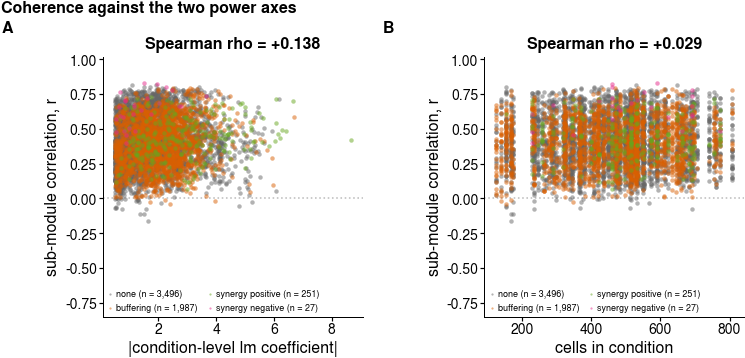

In [18]:
mp = cns.multipanel(max_width=560, title="Coherence against the two power axes",
                    loc="left")
for xcol, xlab, logx in (("lm_estimate_condition", "|condition-level lm coefficient|", False),
                         ("n_cells", "cells in condition", False)):
    ax = mp.panel(width=130, height=130, pad_left=32, margin_bottom=24)
    d = ok.copy()
    if xcol == "lm_estimate_condition":
        d[xcol] = d[xcol].abs()
    for c in CLASS_ORDER:
        dd = d[d.interaction_class == c]
        if not len(dd):
            continue
        ax.scatter(dd[xcol], dd.real_r, s=5, alpha=0.5, linewidths=0,
                   color=CLASS_COLORS[c], label=f"{c} (n = {len(dd):,})",
                   zorder=6 if c.startswith("synergy") else 3)
    if logx:
        ax.set_xscale("log")
    rho = stats.spearmanr(d[xcol], d.real_r).statistic
    ax.set(ylim=(R_LO, R_HI), xlabel=xlab, ylabel=R_LABEL_SHORT)
    ax.axhline(0, color="0.75", ls=":", lw=0.8, zorder=0)
    ax.set_title(f"Spearman rho = {rho:+.3f}")
    ax.legend(frameon=False, fontsize=4.5, loc="lower left", ncol=2)
savefig("coherence_vs_power")

## 7. Does coherence differ by interaction class?

The gate above is on the **condition-level** coefficient, so the gated set spans every
interaction class -- which makes this a direct test of the worry that motivated this notebook:
if synergy calls were an artefact of two ligands acting in two different subpopulations, synergy
pairs specifically would show *lower* sub-module correlation than the rest.

Classes and scores come from the scored lm table. Pairwise p-values are Mann-Whitney U against
`none`.


In [19]:
cls = ok[ok.interaction_class.isin(CLASS_ORDER)].copy()
present_cls = [c for c in CLASS_ORDER if (cls.interaction_class == c).sum() >= 3]
cls = cls[cls.interaction_class.isin(present_cls)]

by_class = (cls.groupby("interaction_class").real_r
            .agg(n="size", median="median", q25=lambda s: s.quantile(.25),
                 q75=lambda s: s.quantile(.75), mean="mean")
            .reindex(present_cls))
kw = stats.kruskal(*[cls.loc[cls.interaction_class == c, "real_r"].to_numpy()
                     for c in present_cls])
ref = cls.loc[cls.interaction_class == "none", "real_r"].to_numpy()
rows = []
for c in present_cls:
    v = cls.loc[cls.interaction_class == c, "real_r"].to_numpy()
    u = stats.mannwhitneyu(v, ref, alternative="two-sided")
    rows.append({"interaction_class": c, "n": v.size, "median_r": float(np.median(v)),
                 "delta_median_vs_none": float(np.median(v) - np.median(ref)),
                 "mwu_p_vs_none": float(u.pvalue),
                 "cles_vs_none": float(u.statistic / (v.size * ref.size))})
by_class_stats = pd.DataFrame(rows)
by_class_stats.to_csv(f"{OUTDIR}/coherence_by_interaction_class.csv", index=False)

print(by_class.to_string())
print(f"\nKruskal-Wallis across {len(present_cls)} classes: H = {kw.statistic:.1f}, "
      f"p = {kw.pvalue:.2e}")
print("\nvs `none` (Mann-Whitney U; CLES = P(r_class > r_none)):")
print(by_class_stats.to_string(index=False))

                      n    median       q25       q75      mean
interaction_class                                              
none               3496  0.398832  0.274957  0.552116  0.409436
buffering          1987  0.403302  0.273172  0.529239  0.400296
synergy positive    251  0.425564  0.328876  0.542408  0.432315
synergy negative     27  0.656771  0.578486  0.714621  0.639514

Kruskal-Wallis across 4 classes: H = 48.6, p = 1.58e-10

vs `none` (Mann-Whitney U; CLES = P(r_class > r_none)):
interaction_class    n  median_r  delta_median_vs_none  mwu_p_vs_none  cles_vs_none
             none 3496  0.398832              0.000000   1.000000e+00      0.500000
        buffering 1987  0.403302              0.004470   1.532347e-01      0.488416
 synergy positive  251  0.425564              0.026732   3.279869e-02      0.540271
 synergy negative   27  0.656771              0.257939   6.880802e-10      0.844086


### `r` by interaction class

The raw distribution per class, with Mann-Whitney p-values against `none`.


In [20]:
ok.columns

Index(['interaction', 'component', 'ligand1', 'ligand2', 'is_self_pair',
       'mirror_interaction', 'lm_estimate_condition', 'lm_p_adj_condition',
       'interaction_class', 'interaction_score', 'estimate_interaction',
       'p_adj_interaction', 'n_cells', 'n_genes_component', 'evaluable',
       'n_genes_used', 'pb_n_A', 'pb_n_B', 'pb_ari_seed', 'real_r'],
      dtype='object')

2026-09-22 22:22:42 | [INFO] P-values were determined by two-sided Mann-Whitney U test.


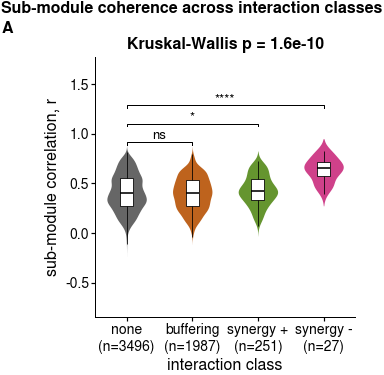

In [21]:
short_order = [CLASS_SHORT[c] for c in present_cls]
cls["class_short"] = cls.interaction_class.map(CLASS_SHORT)
pairs = [(CLASS_SHORT[c], "none") for c in present_cls if c != "none"]
cls_colors = [CLASS_COLORS[c] for c in present_cls]

mp = cns.multipanel(max_width=560, loc="left",
                    title="Sub-module coherence across interaction classes")
ax = mp.panel("A", width=130, height=130, pad_left=32, margin_bottom=24,
              color_cycle=cls_colors)
cns.violinplot(data=cls, x="class_short", y="real_r", order=short_order,
               pairs=pairs, add_count=True, add_box=True, ax=ax,
               hue="class_short", hue_order=short_order, legend=False)
ax.set(xlabel="interaction class", ylabel=R_LABEL_SHORT, ylim=(R_LO, R_HI + 0.75))
ax.set_title(f"Kruskal-Wallis p = {kw.pvalue:.1e}")
savefig("coherence_by_interaction_class")

In [22]:
cls

,interaction,component,ligand1,ligand2,is_self_pair,mirror_interaction,lm_estimate_condition,lm_p_adj_condition,interaction_class,interaction_score,...,p_adj_interaction,n_cells,n_genes_component,evaluable,n_genes_used,pb_n_A,pb_n_B,pb_ari_seed,real_r,class_short
0,IFNG_CCL19,comp_0,IFNG,CCL19,False,None,0.511798,1.898541e-03,none,0.000000,...,9.999775e-01,307.0,212.0,True,212.0,123.0,89.0,1.0,0.469770,none
1,IFNG_IFNA,comp_0,IFNG,IFNA,False,None,3.450270,1.855915e-82,none,0.000000,...,9.999775e-01,333.0,212.0,True,212.0,123.0,89.0,1.0,0.648937,none
2,IFNG_IFNB1,comp_0,IFNG,IFNB1,False,None,4.279498,2.472968e-112,buffering,-0.141313,...,6.657471e-02,124.0,212.0,True,212.0,123.0,89.0,1.0,0.668991,buffering
3,IFNG_IFNK,comp_0,IFNG,IFNK,False,None,3.363504,2.334566e-79,none,0.000000,...,8.958779e-01,264.0,212.0,True,212.0,123.0,89.0,1.0,0.607898,none
4,IFNG_IL2,comp_0,IFNG,IL2,False,IL2_IFNG,-0.644592,7.072337e-05,none,0.000000,...,9.999775e-01,498.0,212.0,True,212.0,123.0,89.0,1.0,0.534851,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5877,TNF_TNFSF15,comp_8,TNF,TNFSF15,False,None,5.163417,6.858293e-217,synergy positive,0.146710,...,1.471464e-05,690.0,121.0,True,121.0,32.0,89.0,1.0,0.356658,synergy +
5878,TNF_TNFSF18,comp_8,TNF,TNFSF18,False,None,5.368933,1.475142e-225,buffering,-0.252793,...,1.077212e-16,346.0,121.0,True,121.0,32.0,89.0,1.0,0.332657,buffering
5879,TNF_TNFSF4,comp_8,TNF,TNFSF4,False,None,4.501326,1.350601e-187,synergy positive,0.090291,...,8.489886e-02,470.0,121.0,True,121.0,32.0,89.0,1.0,0.286411,synergy +
5880,TNF_TNFSF9,comp_8,TNF,TNFSF9,False,None,3.757490,4.171371e-152,synergy positive,0.195321,...,3.075279e-05,371.0,121.0,True,121.0,32.0,89.0,1.0,0.448213,synergy +


In [23]:
from scipy.stats import tukey_hsd
# Tukey HSD across all classes
groups = [cls.loc[cls.class_short == s, "real_r"].to_numpy() for s in short_order]
tukey = tukey_hsd(*groups)
print(f"{'group1':>8} {'group2':>8} {'p-value':>10}")
for i in range(len(short_order)):
    for j in range(i + 1, len(short_order)):
        print(f"{short_order[i]:>8} {short_order[j]:>8} {tukey.pvalue[i, j]:>10.3e}")

  group1   group2    p-value
    none buffering  2.537e-01
    none synergy +  1.946e-01
    none synergy -  9.990e-11
buffering synergy +  3.442e-02
buffering synergy -  1.638e-11
synergy + synergy -  4.366e-08


In [24]:
# print out lowest r synergy pairs
cls.query('class_short == "synergy +"').sort_values("real_r").head(10)

,interaction,component,ligand1,ligand2,is_self_pair,mirror_interaction,lm_estimate_condition,lm_p_adj_condition,interaction_class,interaction_score,...,p_adj_interaction,n_cells,n_genes_component,evaluable,n_genes_used,pb_n_A,pb_n_B,pb_ari_seed,real_r,class_short
3192,IL27_TNFSF15,comp_46,IL27,TNFSF15,False,None,3.003579,3.589424e-136,synergy positive,0.183053,...,6.157107e-04,461.0,48.0,True,48.0,42.0,6.0,1.000000,0.069933,synergy +
4141,IL27_TNF,comp_57,IL27,TNF,False,TNF_IL27,3.008064,2.986238e-141,synergy positive,0.154202,...,4.985484e-03,449.0,49.0,True,49.0,34.0,15.0,1.000000,0.118921,synergy +
4076,IL6_TNFSF18,comp_56,IL6,TNFSF18,False,None,0.537899,1.393566e-15,synergy positive,0.539773,...,2.103254e-02,422.0,207.0,True,207.0,69.0,138.0,1.000000,0.119531,synergy +
4142,IL27_TNFSF15,comp_57,IL27,TNFSF15,False,None,3.067765,9.112443e-145,synergy positive,0.175951,...,5.309428e-04,461.0,49.0,True,49.0,34.0,15.0,1.000000,0.119569,synergy +
3691,TNF_TNFSF15,comp_50,TNF,TNFSF15,False,None,2.904329,2.934040e-133,synergy positive,0.335061,...,6.667604e-12,690.0,81.0,True,81.0,34.0,47.0,1.000000,0.128994,synergy +
439,TNF_TSLP,comp_11,TNF,TSLP,False,None,0.995169,1.714854e-47,synergy positive,0.252463,...,5.855597e-02,544.0,124.0,True,124.0,80.0,44.0,1.000000,0.136756,synergy +
3685,TNF_IL2,comp_50,TNF,IL2,False,IL2_TNF,3.204856,8.622751e-151,synergy positive,0.140180,...,8.434767e-03,664.0,81.0,True,81.0,34.0,47.0,1.000000,0.138994,synergy +
947,IL2_TNFSF4,comp_20,IL2,TNFSF4,False,None,1.741695,1.681438e-43,synergy positive,0.301586,...,1.941058e-02,494.0,76.0,True,76.0,44.0,32.0,0.947366,0.139904,synergy +
769,IL21_CCL21A,comp_17,IL21,CCL21A,False,None,2.207523,5.509768e-74,synergy positive,0.190792,...,6.007232e-02,553.0,88.0,True,88.0,40.0,48.0,1.000000,0.150828,synergy +
3131,IL7_TNFSF4,comp_45,IL7,TNFSF4,False,None,2.140155,1.476163e-78,synergy positive,0.271058,...,6.206480e-04,257.0,94.0,True,94.0,26.0,68.0,0.911917,0.159939,synergy +


In [25]:
# print out lowest r synergy pairs
cls.query('class_short == "synergy -"').sort_values("real_r").head(10)

,interaction,component,ligand1,ligand2,is_self_pair,mirror_interaction,lm_estimate_condition,lm_p_adj_condition,interaction_class,interaction_score,...,p_adj_interaction,n_cells,n_genes_component,evaluable,n_genes_used,pb_n_A,pb_n_B,pb_ari_seed,real_r,class_short
2094,IL27_TNFSF18,comp_32,IL27,TNFSF18,False,None,-0.898117,7.505367e-15,synergy negative,0.769364,...,2.258733e-04,229.0,334.0,True,334.0,224.0,110.0,0.987872,0.395983,synergy -
2149,TNF_TNFSF18,comp_32,TNF,TNFSF18,False,None,-0.888146,1.458667e-14,synergy negative,0.923750,...,4.930474e-06,346.0,334.0,True,334.0,224.0,110.0,0.987872,0.455865,synergy -
50,IL27_TNFSF18,comp_0,IL27,TNFSF18,False,None,-0.544005,9.071450e-04,synergy negative,1.057659,...,9.532354e-02,229.0,212.0,True,212.0,123.0,89.0,1.000000,0.477450,synergy -
2413,IL4_TNF,comp_37,IL4,TNF,False,TNF_IL4,-0.840714,1.630530e-15,synergy negative,0.649960,...,2.368036e-03,662.0,394.0,True,394.0,146.0,248.0,1.000000,0.482188,synergy -
2414,IL4_TNFSF15,comp_37,IL4,TNFSF15,False,None,-1.192883,1.086776e-28,synergy negative,0.379165,...,2.220212e-02,773.0,394.0,True,394.0,146.0,248.0,1.000000,0.487712,synergy -
2134,IL7_TNFSF15,comp_32,IL7,TNFSF15,False,None,-0.981746,2.251757e-17,synergy negative,0.425139,...,9.085090e-02,514.0,334.0,True,334.0,224.0,110.0,0.987872,0.502636,synergy -
2400,IL27_TNFSF15,comp_37,IL27,TNFSF15,False,None,-0.553179,1.604444e-07,synergy negative,1.070540,...,6.877015e-04,461.0,394.0,True,394.0,146.0,248.0,1.000000,0.572341,synergy -
2454,TNF_IL4,comp_37,TNF,IL4,False,IL4_TNF,-0.792745,5.454856e-14,synergy negative,0.508559,...,6.012329e-02,621.0,394.0,True,394.0,146.0,248.0,1.000000,0.584631,synergy -
2148,TNF_TNFSF15,comp_32,TNF,TNFSF15,False,None,-0.693491,1.833887e-09,synergy negative,1.302088,...,3.106132e-07,690.0,334.0,True,334.0,224.0,110.0,0.987872,0.591780,synergy -
3468,IL27_TNFSF18,comp_49,IL27,TNFSF18,False,None,-1.764344,2.220423e-62,synergy negative,0.214722,...,5.607987e-02,229.0,427.0,True,427.0,242.0,185.0,1.000000,0.606399,synergy -


### Coherence vs. interaction strength, within synergy pairs

The class breakdown above shows *whether* synergy pairs differ from the rest on average. This
asks a finer question within the synergy classes themselves -- kept separate since positive and
negative mean opposite things: does `r` track how strong the interaction actually is
(`estimate_interaction`, the GLM's interaction-term coefficient)?


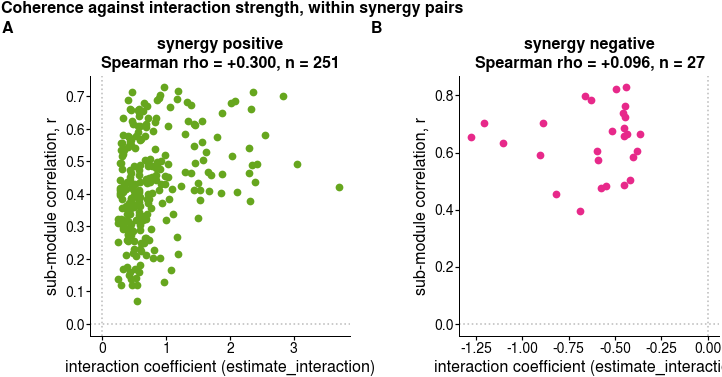

In [26]:
mp = cns.multipanel(max_width=560, loc="left",
                    title="Coherence against interaction strength, within synergy pairs")
for c in ("synergy positive", "synergy negative"):
    ax = mp.panel(width=130, height=130, pad_left=32, margin_bottom=24)
    d = ok[(ok.interaction_class == c) & ok.estimate_interaction.notna()]
    ax.scatter(d.estimate_interaction, d.real_r, s=15, linewidths=0,
               color=CLASS_COLORS[c])
    rho = stats.spearmanr(d.estimate_interaction, d.real_r).statistic if len(d) > 2 else np.nan
    ax.set(xlabel="interaction coefficient (estimate_interaction)",
           ylabel=R_LABEL_SHORT)
    ax.axhline(0, color="0.75", ls=":", lw=0.8, zorder=0)
    ax.axvline(0, color="0.75", ls=":", lw=0.8, zorder=0)
    ax.set_title(f"{c}\nSpearman rho = {rho:+.3f}, n = {len(d):,}")
savefig("coherence_vs_interaction_strength_synergy")

## 8. Synergy pairs at both ends of the range, cell by cell

A distribution summary hides what an individual pair looks like. For pairs classified as
**synergy**, the five with the lowest and the five with the highest sub-module correlation are
plotted directly: one point per cell, module A score against module B score.

The **lowest** five are where a two-subpopulation artefact would be most visible if it were
real. The **highest** five are the other end of the same set, shown for the same reason: a
summary that only ever shows its own tail is hard to trust. `synergy positive` and `synergy
negative` are kept on separate rows -- they mean opposite things and pooling them would be
misleading.


In [27]:
def pair_module_scores(interaction: str, comp: str):
    """Per-cell module A / module B scores for one (interaction, component) pair."""
    part = partitions[comp]
    idx = idx_by_cond[interaction]                       # this condition's cells
    return module_scores(np.asarray(X[np.ix_(idx, part.cols)]), part)

N_SHOW = 5
SYNERGY_CLASSES = ("synergy positive", "synergy negative")

def plot_synergy_cells(end: str, name: str, width: int) -> None:
    """One row per synergy class, one panel per pair: module A vs module B, one point per cell.

    end   "lowest" or "highest" -- which end of that class's r range to show
    name  output file stem
    """
    picked = {}
    for c in SYNERGY_CLASSES:
        d = ok[ok.interaction_class == c]
        picked[c] = (d.nsmallest(N_SHOW, "real_r") if end == "lowest"
                     else d.nlargest(N_SHOW, "real_r").iloc[::-1])
        rs = ", ".join(f"{v:+.3f}" for v in picked[c].real_r) if len(picked[c]) else "-"
        print(f"{end:8s} {c}: {len(d)} pairs measured, {len(picked[c])} shown | r = {rs}")

    # max_width sized so exactly N_SHOW panels fit per row -- one row per synergy class.
    # cns.multipanel.newline() appends a zero-width spacer and does not actually force a wrap.
    mp = cns.multipanel(max_width=width, loc="left",
                        title=f"The {N_SHOW} {end}-r synergy pairs, one point per cell")
    for c, d in picked.items():
        for _, row in d.iterrows():
            ax = mp.panel(width=78, height=78, pad_left=26, pad_top=14)
            score_A, score_B = pair_module_scores(row.interaction, row.component)
            ax.scatter(score_A, score_B, s=10, alpha=0.5, linewidths=0,
                       color=CLASS_COLORS[c])
            ax.set(xlabel="sub-module A score", ylabel="sub-module B score")
            ax.set_title(f"{row.interaction}\n{row.component}, {c.split()[1]}\n"
                         f"r = {row.real_r:+.3f}, n = {int(row.n_cells):,}", fontsize=4.5)
    savefig(name)

def plot_one_pair(interaction: str, comp: str, name: str = None) -> None:
    """Single panel: module A vs module B score, one point per cell, for one (interaction, comp) pair."""
    score_A, score_B = pair_module_scores(interaction, comp)

    match = ok[(ok.interaction == interaction) & (ok.component == comp)]
    if len(match):
        row = match.iloc[0]
        r_val, n_val, c = row.real_r, int(row.n_cells), row.interaction_class
        class_label = c.split()[-1] if " " in c else c  # last word if multi-word, else whole string
        title_extra = f"{class_label}\nr = {r_val:+.3f}, n = {n_val:,}"
        color = CLASS_COLORS.get(c, "black")
    else:
        title_extra = f"n = {len(score_A):,}"
        color = "black"

    mp = cns.multipanel(max_width=120, loc="left",
                        title=f"{interaction} / {comp}")
    ax = mp.panel(width=100, height=100, pad_left=26, pad_top=14)
    ax.scatter(score_A, score_B, s=10, alpha=0.5, linewidths=0, color=color)
    ax.set(xlabel="sub-module A score", ylabel="sub-module B score")
    ax.set_title(f"{interaction}\n{comp}, {title_extra}", fontsize=4.5)

    savefig(name or f"{interaction}_{comp}_pair")

lowest   synergy positive: 251 pairs measured, 5 shown | r = +0.070, +0.119, +0.120, +0.120, +0.129
lowest   synergy negative: 27 pairs measured, 5 shown | r = +0.396, +0.456, +0.477, +0.482, +0.488


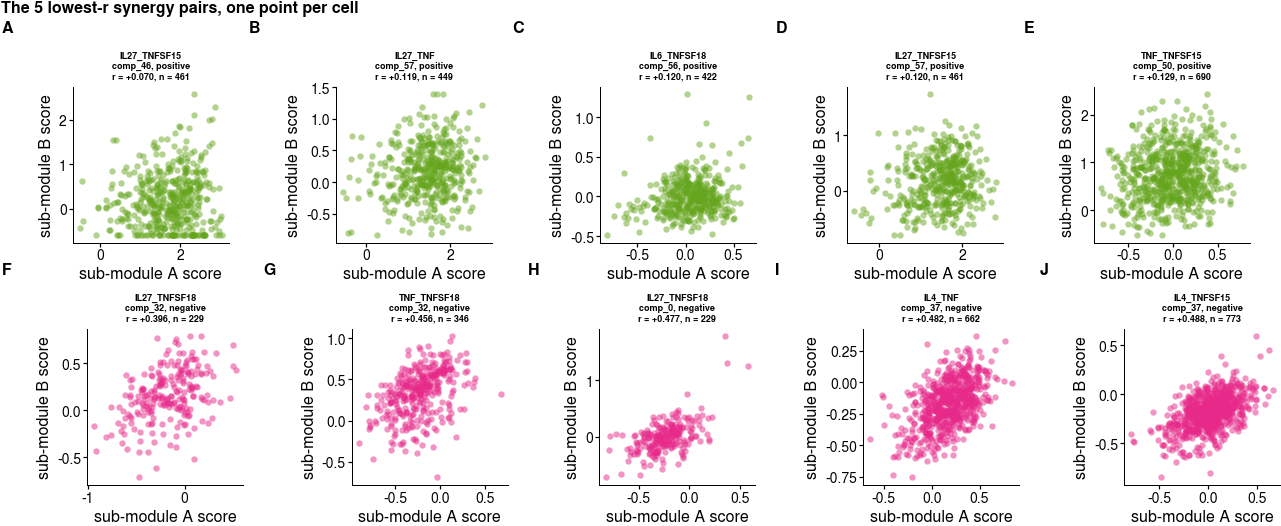

In [28]:
plot_synergy_cells("lowest", "synergy_lowest_r_in_cells", 700)

highest  synergy positive: 251 pairs measured, 5 shown | r = +0.705, +0.712, +0.714, +0.716, +0.727
highest  synergy negative: 27 pairs measured, 5 shown | r = +0.764, +0.783, +0.798, +0.823, +0.828


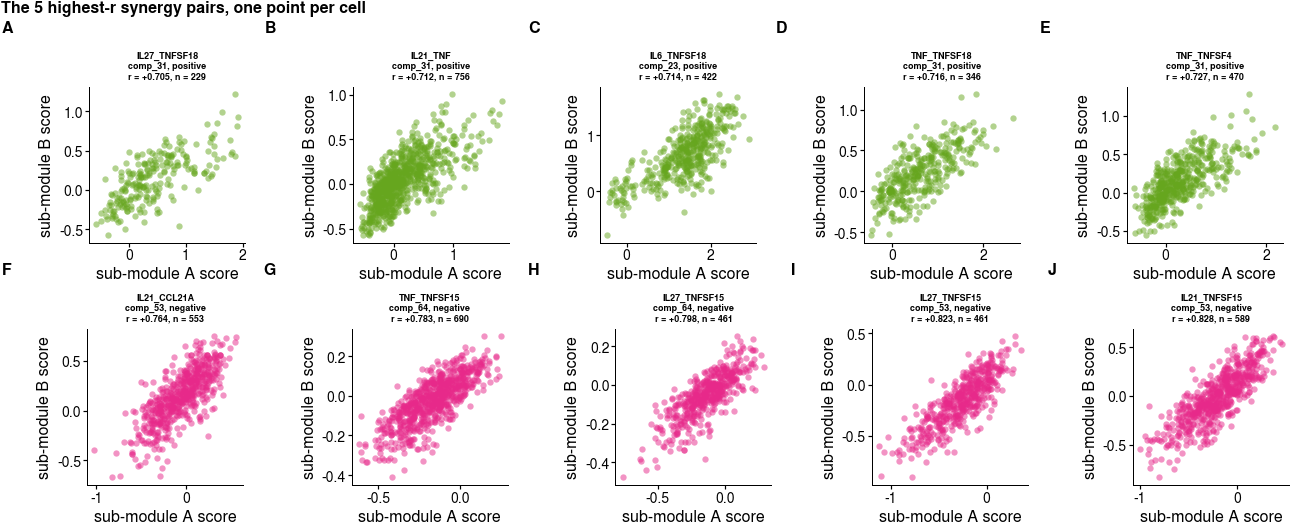

In [29]:
plot_synergy_cells("highest", "synergy_highest_r_in_cells", 700)

## Summary


In [30]:
print(f"gated pairs                   {len(res):,} "
      f"({res.interaction.nunique()} interactions x {res.component.nunique()} components)")
print(f"evaluable with measurable r   {len(ok):,}")
print(f"real_r median                 {ok.real_r.median():+.3f}  "
      f"(IQR {ok.real_r.quantile(.25):+.3f} to {ok.real_r.quantile(.75):+.3f})")
print(f"real_r range                  {ok.real_r.min():+.3f} to {ok.real_r.max():+.3f}")

print("\nby interaction class (median r, and Mann-Whitney vs `none`):")
for _, r_ in by_class_stats.iterrows():
    print(f"  {r_.interaction_class:20s} n = {int(r_.n):5,}  median {r_.median_r:+.3f}  "
          f"delta {r_.delta_median_vs_none:+.3f}  p = {r_.mwu_p_vs_none:.2e}")

print(f"\nmirror concordance            r = {MIRROR_R:.3f}  (n = {len(mok):,})")
print(f"\npartition stability: median ARI across seeds {ARI_MEDIAN:.3f} over "
      f"{len(partitions)} components carried forward")

gated pairs                   5,882 (138 interactions x 68 components)
evaluable with measurable r   5,828
real_r median                 +0.403  (IQR +0.278 to +0.545)
real_r range                  -0.160 to +0.828

by interaction class (median r, and Mann-Whitney vs `none`):
  none                 n = 3,496  median +0.399  delta +0.000  p = 1.00e+00
  buffering            n = 1,987  median +0.403  delta +0.004  p = 1.53e-01
  synergy positive     n =   251  median +0.426  delta +0.027  p = 3.28e-02
  synergy negative     n =    27  median +0.657  delta +0.258  p = 6.88e-10

mirror concordance            r = 0.947  (n = 2,378)

partition stability: median ARI across seeds 1.000 over 78 components carried forward
